# Data Visualization
This notebook describes how the finalized visualization was generated to address the question of interest: 

**Which US jurisdictions (at the county-level) have the highest carbon intensity from operating buildings, measured in tons of CO2 per m^2 per year, averaged over the 2021-2026 period?**

In [46]:
#%pip install duckdb
#%pip install pandas 
import duckdb as duckdb 
import pandas as pd 
import matplotlib.pyplot as plt

In [47]:
# Establish connection 
# Established connection to database
conn = duckdb.connect('/Users/vedikashirtekar/MEDS/EDS-213/eds-213-labs/database/my-db.duckdb')

In [48]:
sources_emissions_top_10 = conn.sql("""SELECT 
    s.source_name, 
    ROUND(
        SUM(e.emissions_quantity) / s.capacity 
        / COUNT(DISTINCT EXTRACT(YEAR FROM e.start_time)), 3 -- Get distinct # of years for a source's emissions records to calculate average annual emissions
    ) AS co2_per_m2_per_year 
FROM sources s
JOIN emission_records e ON s.source_id = e.source_id 
WHERE e.sector = 'buildings' 
  AND s.capacity_units = 'm^2'  
  AND s.capacity > 0 -- Exclude sources with zero capacity to avoid division by zero                                  
GROUP BY s.source_id, s.source_name, s.capacity
ORDER BY co2_per_m2_per_year DESC                         
LIMIT 10;""").df()

In [43]:
sources_emissions_top_10.head()

,source_name,co2_per_m2_per_year
0,Wade Hampton Census Area,0.781
1,Nome Census Area,0.760
2,Kodiak Island Borough,0.550
3,Northwest Arctic Borough,0.469
4,Matanuska-Susitna Borough,0.465


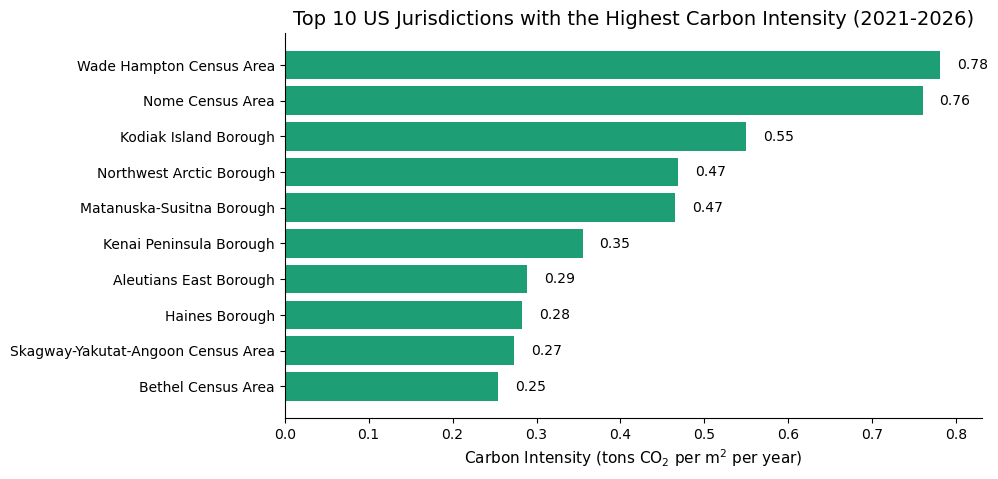

In [44]:
# Establish a fig and axis for bar chart
bars = fig, ax = plt.subplots(figsize=(9, 5))

# Create horizontal bar chart
bars = ax.barh(
    sources_emissions_top_10['source_name'], # y-axis labels
    sources_emissions_top_10['co2_per_m2_per_year'], # x-axis values
    color='#1D9E75', 
    edgecolor='none'
)

ax.invert_yaxis() # Order with highest CO2 intensity at top
ax.set_xlabel("Carbon Intensity (tons CO$_2$ per m$^2$ per year)", fontsize=11) 
ax.set_title("Top 10 US Jurisdictions with the Highest Carbon Intensity (2021-2026)", fontsize=14)
ax.spines[['top', 'right']].set_visible(False) # Remove top and right "bounds"
ax.set_xlim(0, sources_emissions_top_10["co2_per_m2_per_year"].max() + .05)   # Allow some extra space on x-axis for labels

# Add co2 intensity labels to bars
for bar, val in zip(bars, sources_emissions_top_10["co2_per_m2_per_year"]):
    ax.text(val + 0.02, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', va='center', fontsize=10)

plt.savefig('figs/co2_per_m2.png', dpi=150, bbox_inches='tight')
plt.show()

In [49]:
conn.close() #To ensure lock isn't there